# A1 - Aproximación del Valor de Pi

**Professor: Fernando Abraham Fausto Martínez   
Student: Alejandro Caamaño Granados (326056144)    
Course: MCAD 26B  
Due date: 11/sept/26**

## Ejercicio

*Realizar la aproximación del valor de "PI" mediante una simulación de Montecarlo (Simulación Experimental mediante muestreos)*  

*ENTREGABLES:
PDF con código depurado (depurado y subido en forma individual)*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Acorde a los visto en clase, realizaremos una simulación de objetos lanzados aleatoriamente a un cuadradro de lado $L$. Después, calcularemos la distancia euclidiana de cada punto al origen $[0,0]$ para verificar si el punto cayó dentro de el círculo con radio $L$ y centro en $[0,0]$. Finalmente, calcularemos la proporción de objetos dentro y fuera del círculo para aproximar el valor de $\pi$. Realizaremos este experimento con diferentes valores de $n$ para observar el efecto que tiene el tamaño de la muestra en nuestra aproximación.

Primero, crearemos una gráfica para observar los puntos generados y el círculo.

In [2]:
# generate n random points in a 1x1 square
def generate_points_numpy(n):
    # Generates an (n, 2) array where each row is an (x, y) point
    return np.random.rand(n, 2)

# plot points in plot
def plot_points(points):
    plt.scatter(points[:, 0], points[:, 1])
    # add quarter circle starting at 0,0
    circle = plt.Circle((0, 0), 1, color='r', fill=False)
    plt.gca().add_artist(circle)
    plt.axis('equal')
    plt.xlim(0, 1)     # X-axis interval from 2 to 4
    plt.ylim(0, 1)
    plt.show()

Ahora calcularemos la distancia de cada punto a $[0,0]$. Iniciaremos un conteo para cada categoría: Dentro del círculo y Fuera del círculo.

In [3]:
# standard distance formula (slow for Python)
# distances = [math.sqrt(x**2 + y**2) for x, y in points]

# via vectorization (faster)
# axis=1 calculates the norm across each individual point coordinate row
# distances = np.linalg.norm(points, axis=1)

In [4]:
def count_inside_outside(points):
    # compute distance of every point from 0,0
    distances = np.linalg.norm(points, axis=1)
    # count
    num_inside = 0
    num_outside = 0
    for i in range(len(distances)):
        if distances[i] < 1:
            # add 1 to counter
            num_inside += 1
        else:
            num_outside += 1

    print("Number of points inside the circle: ", num_inside)
    print("Number of points outside the circle: ", num_outside)
    return num_inside, num_outside

Finalmente, calculamos $\pi$ usando la fórmula vista en clase.

In [5]:
def approx_pi(num_inside, num_outside):
    # calculate pi
    pi = 4 * num_inside / (num_inside + num_outside)
    # calculate percent error
    pct_error = (abs(pi - np.pi) * 100) / np.pi

    print("Approximated value of pi: ", pi)
    print("Percent error: ", pct_error)
    return pi, pct_error

Hagamos una prueba con un número pequeño de $n$.

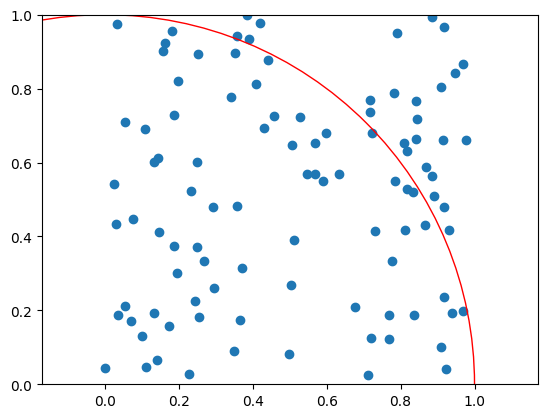

In [6]:
n = 100

points = generate_points_numpy(n)
plot_points(points)

In [7]:
num_inside, num_outside = count_inside_outside(points)
approx_pi(num_inside, num_outside)

Number of points inside the circle:  75
Number of points outside the circle:  25
Approximated value of pi:  3.0
Percent error:  4.507034144862795


(3.0, 4.507034144862795)

Corramos nuestro código con varios valores de $n$ para comparar las aproximaciones.

In [8]:
n_values = [
    10,
    100,
    1000,
    10000,
    100000,
    1000000,
    10000000
]

In [9]:
df_results = pd.DataFrame(columns=['n (Total points)',
                                   'Points inside',
                                   'Points outside',
                                   'Ratio ins/out',
                                   'Approx. Pi',
                                   'Percent error'])

for n in n_values:
    print("For n = ", n)
    points = generate_points_numpy(n)
    num_inside, num_outside = count_inside_outside(points)
    pi, pct_error = approx_pi(num_inside, num_outside)

    df_results.loc[len(df_results)] = [n,
                                       num_inside,
                                       num_outside,
                                       num_inside/num_outside,
                                       pi,
                                       pct_error]

For n =  10
Number of points inside the circle:  8
Number of points outside the circle:  2
Approximated value of pi:  3.2
Percent error:  1.8591635788130245
For n =  100
Number of points inside the circle:  75
Number of points outside the circle:  25
Approximated value of pi:  3.0
Percent error:  4.507034144862795
For n =  1000
Number of points inside the circle:  798
Number of points outside the circle:  202
Approximated value of pi:  3.192
Percent error:  1.6045156698659917
For n =  10000
Number of points inside the circle:  7906
Number of points outside the circle:  2094
Approximated value of pi:  3.1624
Percent error:  0.662318406761962
For n =  100000
Number of points inside the circle:  78578
Number of points outside the circle:  21422
Approximated value of pi:  3.14312
Percent error:  0.04861694619962178
For n =  1000000
Number of points inside the circle:  785685
Number of points outside the circle:  214315
Approximated value of pi:  3.14274
Percent error:  0.03652117052462917


In [10]:
df_results

,n (Total points),Points inside,Points outside,Ratio ins/out,Approx. Pi,Percent error
0,10.0,8.0,2.0,4.000000,3.200000,1.859164
1,100.0,75.0,25.0,3.000000,3.000000,4.507034
2,1000.0,798.0,202.0,3.950495,3.192000,1.604516
3,10000.0,7906.0,2094.0,3.775549,3.162400,0.662318
4,100000.0,78578.0,21422.0,3.668098,3.143120,0.048617
5,1000000.0,785685.0,214315.0,3.666029,3.142740,0.036521
6,10000000.0,7854436.0,2145564.0,3.660779,3.141774,0.005785


Creamos gráfica de aproximaciones de $\pi$ respecto a $n$.

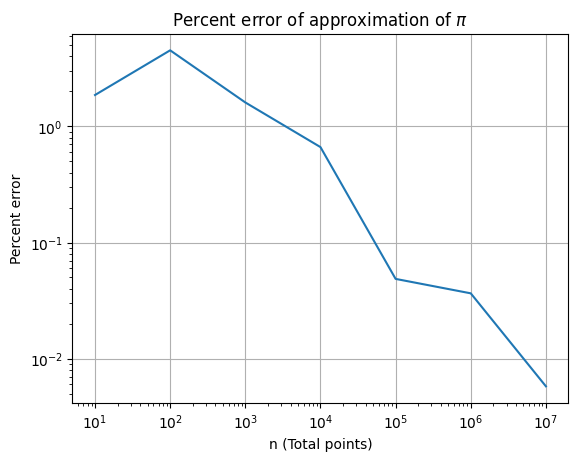

In [12]:
# create log graph of 'Percent error' with respect to n
plt.plot(df_results['n (Total points)'], df_results['Percent error'])
plt.xlabel('n (Total points)')
plt.ylabel('Percent error')
plt.xscale('log')    # Logarithmic X-axis only
plt.yscale('log')    # Logarithmic Y-axis only
plt.grid(True)
plt.title(r'Percent error of approximation of $\pi$')
plt.show()

La gráfica nos muestra que, generalmente, entre mayor el valor de $n$ (más muestras), mejor es nuestra aproximación a $\pi$. Algunas aproximaciones no siguen esta tendencia y muestran mejores resultados que aproximaciones con más muestras. Esto es debido a la aleatoriedad del método que estamos usando, ya que, en algunos casos, se puede dar la coincidencia que un número menor de muestras se aproxime más a la proporción indicada para calcular $\pi$. Este fenómeno será más común cuando $n$ sea menor, porque una coincidencia de este tipo es menos probable entre más representativa sea la muestra.